# EV Adoption Analysis in Irelandime.s.

## Project Overview

This project investigates electric vehicle adoption in Ireland using data analytics and machine learning.

The aim is to explore how selected factors, such as fuel prices, government grant values, and time-based adoption trends, relate to EV sales. The project uses historical data to build predictive models and a scenario simulation prototype.

The scenario simulation allows different future conditions to be tested, such as changes in fuel prices, grant values, and future years. This supports the development of a basic decision-support tool for understanding possible EV adoption outcomes.

The project follows a structured workflow:

1. Data collection
2. Data cleaning and preparation
3. Exploratory data analysis
4. Machine learning modelling
5. Model comparison
6. Scenario simulation
7. Evaluation and limitations

In [2]:
# ================================
# Importing required libraries
# ================================

import pandas as pd        # Data manipulation and analysis
import numpy as np         # Numerical operations
import matplotlib.pyplot as plt  # Data visualisation
import seaborn as sns        #correlation heatmap

In [3]:
# Confirm that the environment is correctly set up
print("Environment setup complete")

Environment setup complete


In [4]:
# Display versions to ensure consistency across environments
print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)

Pandas version: 2.2.2
Numpy version: 1.26.4


## Datasets Used

This project uses multiple datasets to analyse EV adoption in Ireland.

### EV Sales Datset

The EV sales dataset provides annual electric vehicle sales data. It is used as the main target variable for the machine learning mdels.

The target varible is:

- ev_sales: annual number of electric vehicles sold

### Fuel Pice Dataset

The fuel price dataset provides petrol and diesel price data over time. Monthly fuel prices were processed and aggregated into an anual average.

The main feature created from his dataset is:

- fuel_price: average yearly fuel price

## EV Grant Dataset

The grant dataset represents government purchase grant values for electric vehicles. This was included to explore whether financial incentives are assciated with EV sales.

The main feature is:

- grant_value: EV grant amount available in each year
### Final Modelling Dataset

The final modelling dataset combines EV sales, fuel prices, grant values, and year into one table. This dataset is used to train and evaluate the machine learning models.

In [199]:
# Load datasets
# EV dataset (contains EV sales, stock, charging points, etc.)
ev_df = pd.read_excel('EVDataExplorer2025.xlsx')

# Fuel price dataset (consumer price data including petrol and diesel)
fuel_df = pd.read_csv('CPM12.20260312T150355.csv')

# Transport dataset (to be explored later for additional variables)
transport_df = pd.read_csv('TEM12.20260312T150343.csv')

#Tax dataset (EV tax relief)
eta02 = pd.read_excel("ETA02.20260506T100529.xlsx")

## Exploring the EV Sales Dataset

In this section, we perform an initial exploration of the EV dataset to understand its structure, variables, and data quality before focusing specifically on Ireland.

In [7]:
# Preview the dataset to understand its structure and variables
ev_df.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
0,World,Projection-STEPS,EV stock,2 and 3 wheelers,BEV,2030,Vehicles,170000000.0,_World
1,World,Projection-STEPS,EV stock,Cars,BEV,2030,Vehicles,150000000.0,_World
2,China,Projection-STEPS,EV stock,2 and 3 wheelers,BEV,2030,Vehicles,91000000.0,Other
3,China,Projection-STEPS,EV stock,Cars,BEV,2030,Vehicles,82000000.0,Other
4,World,Projection-STEPS,EV stock,Cars,PHEV,2030,Vehicles,82000000.0,_World


In [8]:
# Display dataset structure, data types, and non-null counts
ev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16436 entries, 0 to 16435
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   region_country   16436 non-null  object 
 1   category         16436 non-null  object 
 2   parameter        16436 non-null  object 
 3   mode             16436 non-null  object 
 4   powertrain       16436 non-null  object 
 5   year             16436 non-null  int64  
 6   unit             16436 non-null  object 
 7   value            16436 non-null  float64
 8   Aggregate group  16436 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 1.1+ MB


In [9]:
# Summary statistics for numerical columns (year and value)
ev_df.describe()

,year,value
count,16436.000000,1.643600e+04
mean,2018.852336,2.678267e+05
std,4.271488,3.325613e+06
min,2010.000000,1.200000e-06
25%,2016.000000,1.000000e+00
50%,2019.000000,4.900000e+01
75%,2022.000000,2.500000e+03
max,2030.000000,1.700000e+08


In [10]:
# Check for missing values across all columns
ev_df.isnull().sum()

region_country     0
category           0
parameter          0
mode               0
powertrain         0
year               0
unit               0
value              0
Aggregate group    0
dtype: int64

No missing values are present in the dataset, indicating it is clean and suitable for analysis.

#### Initial Global Trend (Unfiltered Data)

This plot shows EV values across all regions and categories. 
However, it is not meaningful for analysis because it mixes multiple countries, vehicle types, and projections.

A more focused dataset is required.

In [13]:
# Filter dataset for Ireland only (all parameters and vehicle types)
ireland_data = ev_df[ev_df['region_country'] == 'Ireland']

# Preview filtered data
ireland_data.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
2063,Ireland,Historical,EV sales,Cars,BEV,2023,Vehicles,23000.0,Other
2284,Ireland,Historical,EV sales,Cars,BEV,2024,Vehicles,17000.0,Other
2334,Ireland,Historical,EV sales,Cars,BEV,2022,Vehicles,16000.0,Other
2495,Ireland,Historical,EV sales,Cars,PHEV,2024,Vehicles,13000.0,Other
2704,Ireland,Historical,EV sales,Cars,PHEV,2023,Vehicles,10000.0,Other


In [14]:
# Explore unique values to understand dataset dimensions
ev_df['parameter'].unique()   # What is being measured (sales, stock, charging points, etc.)
ev_df['mode'].unique()       # Vehicle types
ev_df['powertrain'].unique() # Technology type (BEV, PHEV, etc.)

array(['BEV', 'PHEV', 'Publicly available slow',
       'Publicly available fast', 'EV', 'FCEV'], dtype=object)

The dataset contains multiple parameters (e.g., EV sales, stock, charging points), 
different vehicle types, and multiple powertrain technologies. 

For this project, we focus specifically on:
- EV sales
- Cars only
- BEV (Battery Electric Vehicles)

In [16]:
# Filter dataset to focus on:
# - Ireland
# - EV sales only
# - Cars (exclude buses, vans, etc.)
# - BEV (Battery Electric Vehicles)

ireland_ev = ev_df[
    (ev_df['region_country'] == 'Ireland') &
    (ev_df['parameter'] == 'EV sales') &
    (ev_df['mode'] == 'Cars') &
    (ev_df['powertrain'] == 'BEV')
]

In [17]:
# Sort data chronologically for time series analysis
ireland_ev = ireland_ev.sort_values(by='year')

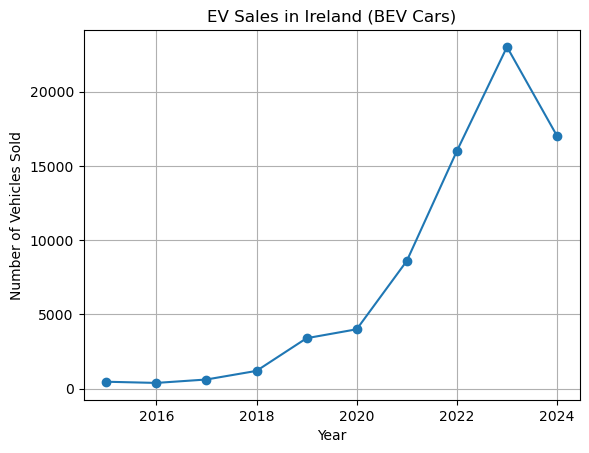

In [18]:
# Plot EV sales trend in Ireland over time
plt.plot(ireland_ev['year'], ireland_ev['value'], marker='o')

plt.title('EV Sales in Ireland (BEV Cars)')
plt.xlabel('Year')
plt.ylabel('Number of Vehicles Sold')

plt.grid()
plt.show()

The plot shows a clear upward trend in EV adoption in Ireland, 
with significant growth after 2020, indicating accelerating adoption rates.

In [20]:
# Create separate datasets for BEV and PHEV comparison

bev = ev_df[
    (ev_df['region_country'] == 'Ireland') &
    (ev_df['parameter'] == 'EV sales') &
    (ev_df['mode'] == 'Cars') &
    (ev_df['powertrain'] == 'BEV')
]

phev = ev_df[
    (ev_df['region_country'] == 'Ireland') &
    (ev_df['parameter'] == 'EV sales') &
    (ev_df['mode'] == 'Cars') &
    (ev_df['powertrain'] == 'PHEV')
]

# Sort both datasets
bev = bev.sort_values(by='year')
phev = phev.sort_values(by='year')

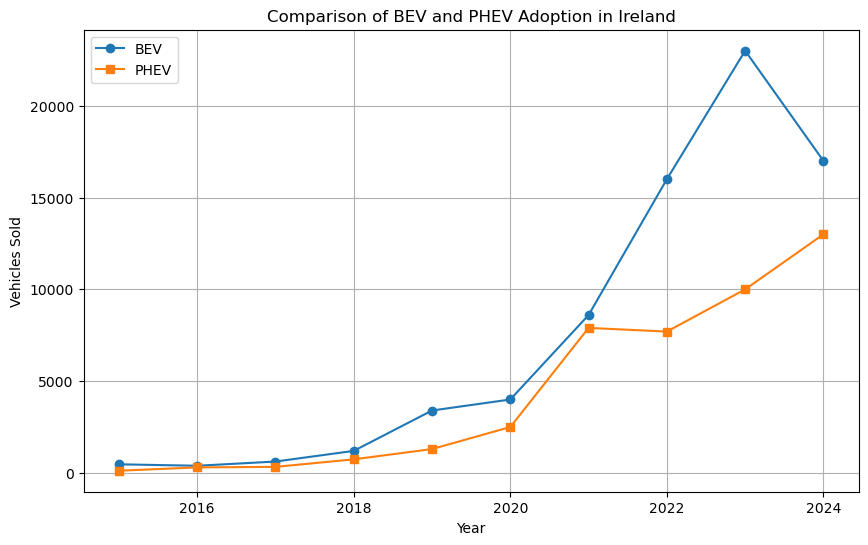

In [21]:
# Compare BEV vs PHEV adoption over time
plt.figure(figsize=(10,6))

plt.plot(bev['year'], bev['value'], marker='o', label='BEV')
plt.plot(phev['year'], phev['value'], marker='s', label='PHEV')

plt.title('Comparison of BEV and PHEV Adoption in Ireland')
plt.xlabel('Year')
plt.ylabel('Vehicles Sold')

plt.legend()
plt.grid()
plt.show()

BEVs show significantly stronger growth compared to PHEVs, 
suggesting a shift towards fully electric vehicles in Ireland.

## EV Adoption Trends in Ireland (BEV vs PHEV)

The graph above illustrates the growth in electric vehicle adoption in Ireland between 2015 and 2024, comparing Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs).

From the data, it is evident that BEVs have experienced significantly faster growth, particularly after 2020, indicating a shift towards fully electric vehicles. While PHEVs have also increased over time, their growth has been more gradual, suggesting they may serve as a transitional technology rather than a long-term solution.

A slight decline in BEV sales is observed in 2024, which may be attributed to external factors such as changes in government incentives, economic conditions, or supply constraints. This highlights the importance of considering external variables when analysing EV adoption trends.

Overall, the data demonstrates a strong upward trend in EV adoption in Ireland, supporting the argument that electric vehicles are becoming increasingly mainstream.ngly mainstream.

### Fuel Prices Dataset Exploration

This section explores fuel price data in Ireland to understand trends in petrol and diesel prices over time, which will later be used as a factor influencing EV adoption.

In [25]:
# Preview fuel dataset to understand its structure and contents
fuel_df.head()

,STATISTIC Label,Month,Consumer Item,UNIT,VALUE
0,National Average Price,2011 December,"White, self raising flour per 2 kg",Euro,NaN
1,National Average Price,2011 December,"Brown, wholemeal flour per 2 kg",Euro,NaN
2,National Average Price,2011 December,"Bread, white sliced pan, large (800g)",Euro,NaN
3,National Average Price,2011 December,"Bread, brown sliced pan, large (800g)",Euro,NaN
4,National Average Price,2011 December,Spaghetti per 500g,Euro,NaN


In [26]:
# Inspect dataset structure, data types, and missing values
fuel_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12996 entries, 0 to 12995
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   STATISTIC Label  12996 non-null  object 
 1   Month            12996 non-null  object 
 2   Consumer Item    12996 non-null  object 
 3   UNIT             12996 non-null  object 
 4   VALUE            11679 non-null  float64
dtypes: float64(1), object(4)
memory usage: 507.8+ KB


In [27]:
# Summary statistics for fuel prices
fuel_df.describe()

,VALUE
count,11679.000000
mean,8.407206
std,8.783095
min,0.767000
25%,2.065000
50%,5.037000
75%,11.591500
max,57.321000


In [28]:
# Check for missing values
fuel_df.isnull().sum()

STATISTIC Label       0
Month                 0
Consumer Item         0
UNIT                  0
VALUE              1317
dtype: int64

The dataset contains missing values in the price column, which will need to be handled during preprocessing.

In [30]:
# Filter dataset to include only fuel-related items (petrol and diesel)
fuel_prices = fuel_df[
    fuel_df['Consumer Item'].str.contains('petrol|diesel|fuel', case=False, na=False)
].copy()

fuel_prices.head()

,STATISTIC Label,Month,Consumer Item,UNIT,VALUE
69,National Average Price,2011 December,Diesel per litre,Euro,NaN
70,National Average Price,2011 December,Petrol - unleaded per litre,Euro,NaN
145,National Average Price,2012 January,Diesel per litre,Euro,1.529
146,National Average Price,2012 January,Petrol - unleaded per litre,Euro,1.542
221,National Average Price,2012 February,Diesel per litre,Euro,1.554


In [31]:
# Convert 'Month' column to datetime format and extract year
fuel_prices['Month'] = pd.to_datetime(fuel_prices['Month'], format='%Y %B')
fuel_prices['year'] = fuel_prices['Month'].dt.year

fuel_prices.head()

,STATISTIC Label,Month,Consumer Item,UNIT,VALUE,year
69,National Average Price,2011-12-01,Diesel per litre,Euro,NaN,2011
70,National Average Price,2011-12-01,Petrol - unleaded per litre,Euro,NaN,2011
145,National Average Price,2012-01-01,Diesel per litre,Euro,1.529,2012
146,National Average Price,2012-01-01,Petrol - unleaded per litre,Euro,1.542,2012
221,National Average Price,2012-02-01,Diesel per litre,Euro,1.554,2012


The date column is converted into a datetime format to enable time-based analysis and aggregation by year.ar

In [33]:
# Separate petrol and diesel datasets
petrol = fuel_prices[
    fuel_prices['Consumer Item'].str.contains('petrol', case=False, na=False)
]

diesel = fuel_prices[
    fuel_prices['Consumer Item'].str.contains('diesel', case=False, na=False)
]

Fuel data is split into petrol and diesel categories to compare trends between both fuel types.

The graph shows fluctuations in fuel prices over time, with a noticeable increase around 2021–2022, likely influenced by global economic factors.

These fluctuations are important as rising fuel prices may encourage consumers to switch to electric vehicles.

#### Fuel Prices in Ireland Over Time

This graph illustrates the trend in petrol and diesel prices in Ireland over time. 

Both fuel types follow a similar pattern, with a noticeable decline around 2015–2016, followed by a steady increase. A significant spike is observed around 2021–2022, likely influenced by global economic factors such as supply chain disruptions and geopolitical events.

Understanding these fluctuations is important, as rising fuel prices may influence consumer decisions and encourage a shift towards electric vehicles.

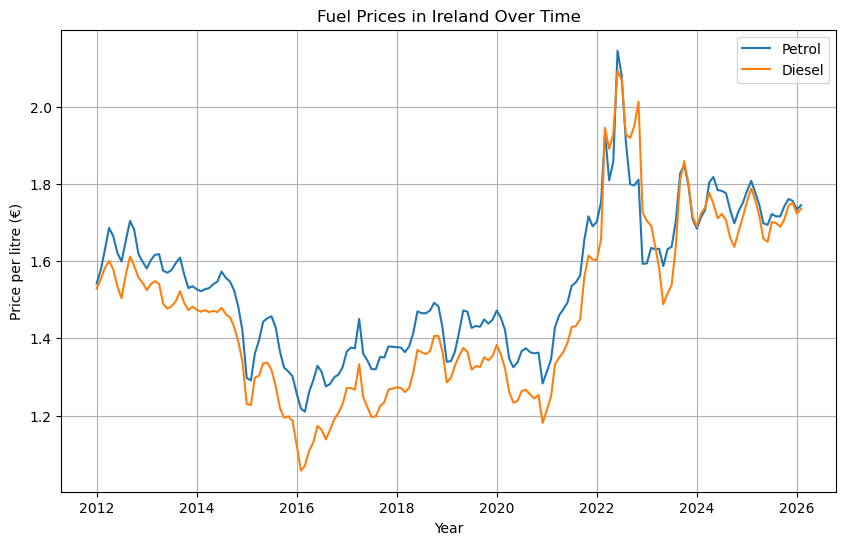

In [37]:
# Plot petrol and diesel price trends over time
plt.figure(figsize=(10,6))

# Line plot for petrol prices
plt.plot(petrol['Month'], petrol['VALUE'], label='Petrol')

# Line plot for diesel prices
plt.plot(diesel['Month'], diesel['VALUE'], label='Diesel')

# Titles and labels
plt.title('Fuel Prices in Ireland Over Time')
plt.xlabel('Year')
plt.ylabel('Price per litre (€)')

# Legend and grid for readability
plt.legend()
plt.grid()

plt.show()

#### Relationship Between Fuel Prices and EV Adoption

This scatter plot shows the relationship between average fuel prices and EV sales in Ireland.

A positive trend can be observed, where higher fuel prices are generally associated with increased EV adoption. This suggests that as traditional fuel becomes more expensive, consumers may be more inclined to switch to electric vehicles.

However, the relationship is not perfectly linear, indicating that other factors (such as government incentives, infrastructure, and technology improvements) also play a significant role.

In [39]:
# Calculate average fuel price per year
fuel_yearly = fuel_prices.groupby('year')['VALUE'].mean().reset_index()

In [40]:
# Prepare EV dataset for merging
ireland_ev = ireland_ev[['year', 'value']]
ireland_ev = ireland_ev.rename(columns={'value': 'ev_sales'})

# Merge EV sales with yearly fuel prices
merged_df = pd.merge(ireland_ev, fuel_yearly, on='year')

In [41]:
# Rename fuel price column for clarity
merged_df = merged_df.rename(columns={'VALUE': 'fuel_price'})

In [42]:
# Inspect merged dataset to confirm correct alignment
merged_df.head()

,year,ev_sales,fuel_price
0,2015,470.0,1.314583
1,2016,390.0,1.213292
2,2017,620.0,1.306917
3,2018,1200.0,1.383625
4,2019,3400.0,1.377250


In [43]:
# Merge EV sales data with yearly fuel price data
merged_df = pd.merge(
    ireland_ev,
    fuel_yearly,
    on='year',
    how='inner'
)

# Rename VALUE column to fuel_price if needed
merged_df = merged_df.rename(columns={'VALUE': 'fuel_price'})

# Preview merged dataset
merged_df.head()

,year,ev_sales,fuel_price
0,2015,470.0,1.314583
1,2016,390.0,1.213292
2,2017,620.0,1.306917
3,2018,1200.0,1.383625
4,2019,3400.0,1.377250


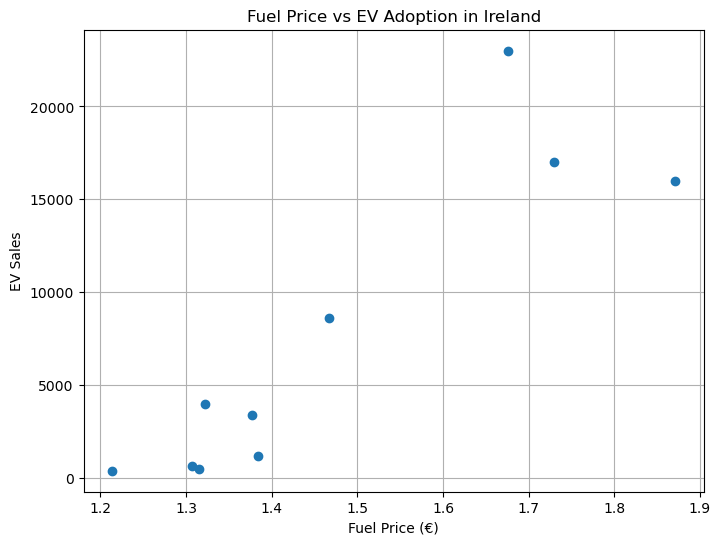

In [44]:
# Scatter plot to examine relationship between fuel prices and EV sales
plt.figure(figsize=(8,6))

# Plot each data point (fuel price vs EV sales)
plt.scatter(merged_df['fuel_price'], merged_df['ev_sales'])

# Titles and labels
plt.title('Fuel Price vs EV Adoption in Ireland')
plt.xlabel('Fuel Price (€)')
plt.ylabel('EV Sales')

# Grid for better visual interpretation
plt.grid()

plt.show()

#### EV Sales and Fuel Prices Over Time

This graph combines EV sales and fuel prices over time using two y-axes, allowing for direct comparison of their trends.

A strong increase in EV adoption is observed after 2020, which coincides with a period of rising fuel prices. This visual comparison supports the hypothesis that fuel price increases may contribute to higher EV adoption.

However, the growth in EV sales is more rapid than fuel price changes alone would explain, suggesting that additional factors such as policy incentives, environmental awareness, and improvements in EV technology are also driving adoption.

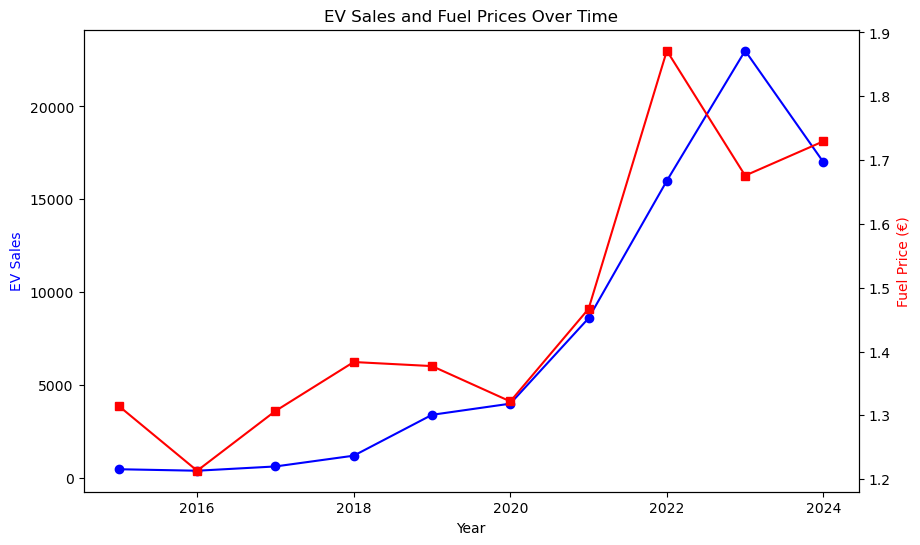

In [46]:
# Dual-axis plot to compare EV sales and fuel prices over time
fig, ax1 = plt.subplots(figsize=(10,6))

# Left axis: EV sales
ax1.set_xlabel('Year')
ax1.set_ylabel('EV Sales', color='blue')
ax1.plot(merged_df['year'], merged_df['ev_sales'], color='blue', marker='o')

# Right axis: Fuel prices
ax2 = ax1.twinx()
ax2.set_ylabel('Fuel Price (€)', color='red')
ax2.plot(merged_df['year'], merged_df['fuel_price'], color='red', marker='s')

# Title
plt.title('EV Sales and Fuel Prices Over Time')

plt.show()

Fuel prices are aggregated by year to align with the EV sales dataset, enabling direct comparison and modelling.

In [48]:
## Relationship Between EV Sales and Fuel Prices

To analyse the relationship between EV adoption and fuel prices, both datasets are merged based on the year.

This allows us to directly compare EV sales with average fuel prices over the same time period.

The scatter plot shows a positive relationship between fuel prices and EV sales.

As fuel prices increase, EV adoption tends to increase as well, suggesting that higher fuel costs may encourage consumers to switch to electric vehicles.

## Visualising relantionship between 1st and 2nd dataset (EV sales and Petrol/diesel price fluctuation)

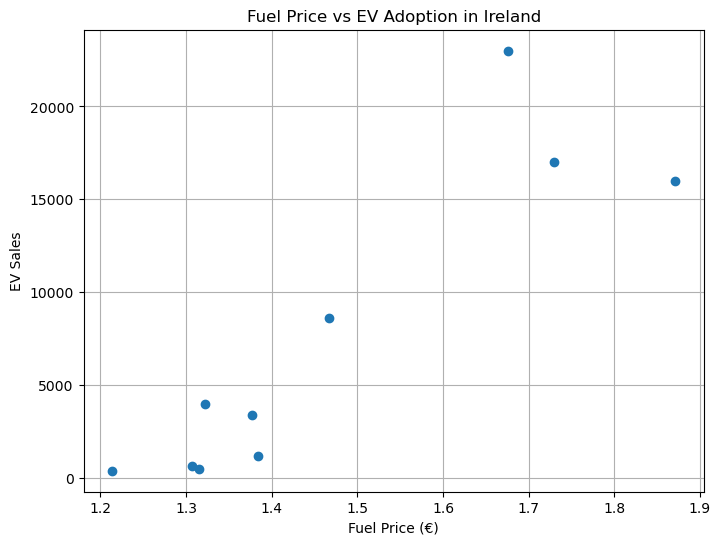

In [52]:
# Select only the relevant columns (year and EV sales)
# Used a copy to avoid modifying the original dataframe
ireland_ev_model = ireland_ev[['year', 'ev_sales']].copy()

# Merge EV sales data with yearly fuel price data using 'year' as the common key
# This allows to analyse both variables over the same time period
merged_df = pd.merge(ireland_ev_model, fuel_yearly, on='year')


# Rename 'VALUE' column (from fuel dataset) to a clearer name
merged_df = merged_df.rename(columns={'VALUE': 'fuel_price'})

# Create a scatter plot to explore the relationship between fuel prices and EV sales
plt.figure(figsize=(8,6))

# Each point represents a year (fuel price vs EV sales)
plt.scatter(merged_df['fuel_price'], merged_df['ev_sales'])

# Add descriptive title and axis labels
plt.title('Fuel Price vs EV Adoption in Ireland')
plt.xlabel('Fuel Price (€)')
plt.ylabel('EV Sales')

# Add grid to improve readability of the plot
plt.grid()

# Display the plot
plt.show()

### Relationship Between Fuel Prices and EV Adoption

The scatter plot above illustrates the relationship between average fuel prices and electric vehicle (EV) adoption in Ireland.

A positive association can be observed, where higher fuel prices tend to correspond with higher EV sales. This suggests that increases in fuel costs may influence consumer behaviour, encouraging a shift towards electric vehicles as a more cost-efficient alternative.

However, it is important to note that this relationship is not strictly causal. Other factors such as government incentives, technological advancements, and the expansion of charging infrastructure also play a significant role in EV adoption.

Overall, the analysis supports the hypothesis that rising fuel prices are one of several contributing factors driving the growth of electric vehicles in Ireland.les.

## Transport Tax Dataset Exploration (ETA02)

This section explores CSO environmental tax data related to transport. 
The purpose is to understand whether broader transport taxation trends can provide useful context for EV adoption in Ireland.

In [55]:
# ================================
# Load ETA02 Environmental Taxes Dataset
# ================================

eta02 = pd.read_excel('ETA02.20260506T100529.xlsx')

# Preview the dataset
eta02.head()

,Unnamed: 0,Unnamed: 1
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


In [56]:
# Check the sheet names inside the ETA02 Excel file
excel_file = pd.ExcelFile('ETA02.20260506T100529.xlsx')

excel_file.sheet_names

['About', 'Unpivoted', 'Pivoted']

In [57]:
# Load the Pivoted sheet instead of the default About sheet
eta02 = pd.read_excel(
    'ETA02.20260506T100529.xlsx',
    sheet_name='Pivoted'
)

# Preview the dataset
eta02.head()

""


In [58]:
# Check structure and column types
eta02.info()

# Display column names
eta02.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Empty DataFrame


RangeIndex(start=0, stop=0, step=1)

In [59]:
# Try loading the Pivoted sheet while skipping metadata rows
eta02 = pd.read_excel(
    'ETA02.20260506T100529.xlsx',
    sheet_name='Pivoted',
    skiprows=10
)

# Preview dataset again
eta02.head(15)

""


In [60]:
# Check unique values in each column to understand categories
for col in eta02.columns:
    print(f"\n{col}")
    print(eta02[col].unique()[:10])

In [61]:
# Load Pivoted sheet with NO headers
raw_eta02 = pd.read_excel(
    'ETA02.20260506T100529.xlsx',
    sheet_name='Pivoted',
    header=None
)

# Display first 30 rows
print(raw_eta02.head(30).to_string())

Empty DataFrame
Columns: []
Index: []


In [62]:
# Load the Unpivoted sheet
eta02 = pd.read_excel(
    'ETA02.20260506T100529.xlsx',
    sheet_name='Unpivoted'
)

# Preview dataset
eta02.head()

,STATISTIC,Statistic Label,TLIST(A1),Year,C03812V04561,Transport taxes,UNIT,VALUE
0,ETA02C01,Tax type,2009,2009,21,Vehicle registration tax,€m,372.99
1,ETA02C01,Tax type,2009,2009,22,Air travel tax,€m,91.91
2,ETA02C01,Tax type,2009,2009,23,National Car Test (NCT) Levy,€m,0.00
3,ETA02C01,Tax type,2009,2009,24,Motor tax (business),€m,264.45
4,ETA02C01,Tax type,2009,2009,25,Motor tax (households),€m,787.36


In [63]:
# Check structure of the correct ETA02 dataset
eta02.info()

# Check available transport tax categories
eta02['Transport taxes'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   STATISTIC        112 non-null    object 
 1   Statistic Label  112 non-null    object 
 2   TLIST(A1)        112 non-null    int64  
 3   Year             112 non-null    int64  
 4   C03812V04561     112 non-null    object 
 5   Transport taxes  112 non-null    object 
 6   UNIT             112 non-null    object 
 7   VALUE            112 non-null    float64
dtypes: float64(1), int64(2), object(5)
memory usage: 7.1+ KB


array(['Vehicle registration tax', 'Air travel tax',
       'National Car Test (NCT) Levy', 'Motor tax (business)',
       'Motor tax (households)', 'Vehicle and driving licence expenses',
       'All Transport Taxes'], dtype=object)

In [64]:
# Filter the most relevant transport tax categories
eta02_relevant = eta02[
    eta02['Transport taxes'].isin([
        'Vehicle registration tax',
        'Motor tax (households)',
        'Motor tax (business)',
        'All Transport Taxes'
    ])
]

eta02_relevant.head()

,STATISTIC,Statistic Label,TLIST(A1),Year,C03812V04561,Transport taxes,UNIT,VALUE
0,ETA02C01,Tax type,2009,2009,21,Vehicle registration tax,€m,372.99
3,ETA02C01,Tax type,2009,2009,24,Motor tax (business),€m,264.45
4,ETA02C01,Tax type,2009,2009,25,Motor tax (households),€m,787.36
6,ETA02C01,Tax type,2009,2009,-,All Transport Taxes,€m,1522.71
7,ETA02C01,Tax type,2010,2010,21,Vehicle registration tax,€m,394.88


### Vehicle Registration Tax Over Time

This visualization explores changes in Vehicle Registration Tax (VRT) revenue over time in Ireland. 
The graph helps provide fiscal and policy context related to transport and vehicle ownership.

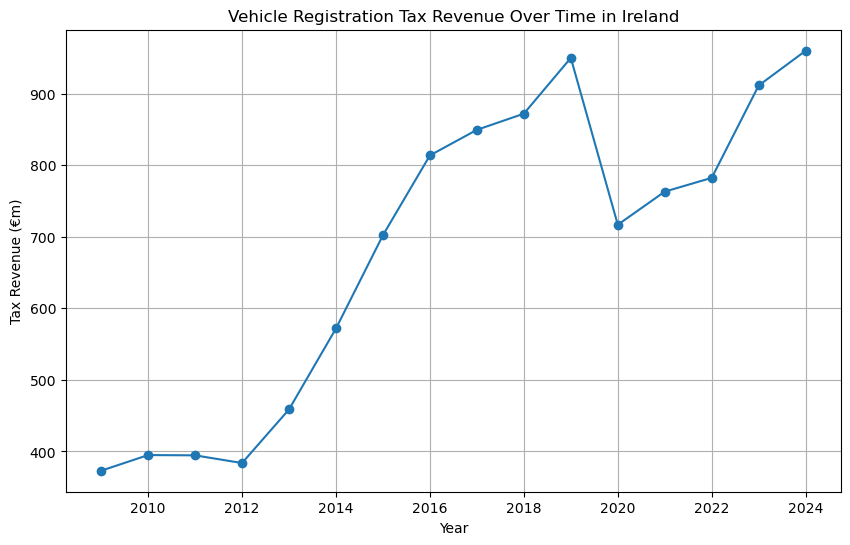

In [66]:
# Filter Vehicle Registration Tax data only
vrt_tax = eta02[
    eta02['Transport taxes'] == 'Vehicle registration tax'
]

# Create the graph
plt.figure(figsize=(10,6))

plt.plot(
    vrt_tax['Year'],
    vrt_tax['VALUE'],
    marker='o'
)

# Titles and labels
plt.title('Vehicle Registration Tax Revenue Over Time in Ireland')
plt.xlabel('Year')
plt.ylabel('Tax Revenue (€m)')

# Grid for readability
plt.grid()

# Show graph
plt.show()

## EV Grant Data Integration

This section manually creates a dataset containing EV purchase grant values in Ireland over time. 
The grant data is included as a policy-related variable to help explore how government incentives may influence EV adoption.

In [68]:
# Create EV Grant Dataset
grant_data = {
    'year': [2011, 2012, 2013, 2014, 2015,
             2016, 2017, 2018, 2019, 2020,
             2021, 2022, 2023, 2024],
    
    'grant_value': [5000, 5000, 5000, 5000, 5000,
                    5000, 5000, 5000, 5000, 5000,
                    5000, 5000, 3500, 3500]
}

# Convert dictionary into dataframe
grant_df = pd.DataFrame(grant_data)

# Preview dataset
grant_df.head()

,year,grant_value
0,2011,5000
1,2012,5000
2,2013,5000
3,2014,5000
4,2015,5000


### EV Grant Values Over Time

This graph visualizes the evolution of EV purchase grants in Ireland and highlights changes in government incentives over time.

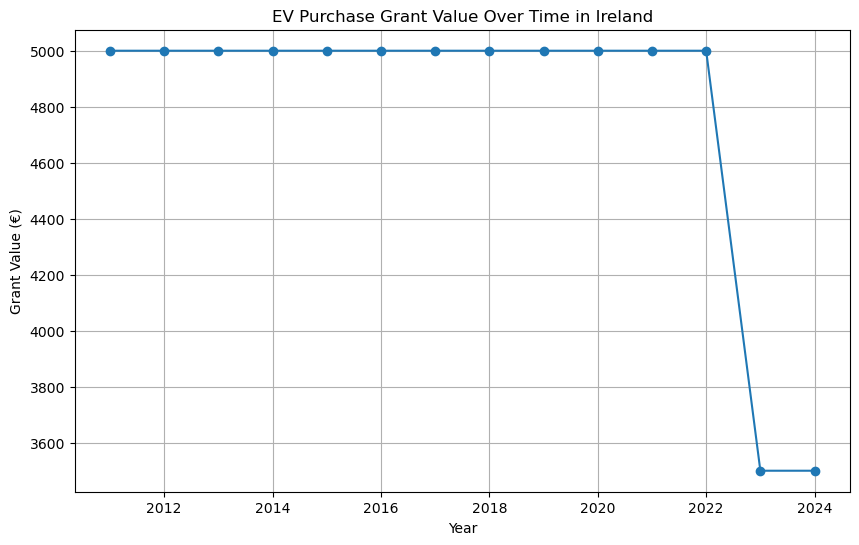

In [70]:
# Plot EV grant values over time
plt.figure(figsize=(10,6))

plt.plot(
    grant_df['year'],
    grant_df['grant_value'],
    marker='o'
)

# Titles and labels
plt.title('EV Purchase Grant Value Over Time in Ireland')
plt.xlabel('Year')
plt.ylabel('Grant Value (€)')

# Grid for readability
plt.grid()

# Show graph
plt.show()

## Final Modeling Dataset

This section merges EV adoption, fuel price, and EV grant data into a single dataset that will be used for machine learning and predictive analysis.

In [72]:
# ================================
# Create Final Modeling Dataset
# ================================

# Merge EV/fuel dataset with grant dataset
final_model_df = pd.merge(
    merged_df,
    grant_df,
    on='year',
    how='left'
)

# Preview final dataset
final_model_df.head()

,year,ev_sales,fuel_price,grant_value
0,2015,470.0,1.314583,5000
1,2016,390.0,1.213292,5000
2,2017,620.0,1.306917,5000
3,2018,1200.0,1.383625,5000
4,2019,3400.0,1.377250,5000


In [73]:
# Check structure of final modeling dataset
final_model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   year         10 non-null     int64  
 1   ev_sales     10 non-null     float64
 2   fuel_price   10 non-null     float64
 3   grant_value  10 non-null     int64  
dtypes: float64(2), int64(2)
memory usage: 452.0 bytes


In [74]:
# Summary statistics
final_model_df.describe()

,year,ev_sales,fuel_price,grant_value
count,10.00000,10.000000,10.000000,10.000000
mean,2019.50000,7468.000000,1.466117,4700.000000
std,3.02765,8299.980991,0.217389,632.455532
min,2015.00000,390.000000,1.213292,3500.000000
25%,2017.25000,765.000000,1.316406,5000.000000
50%,2019.50000,3700.000000,1.380438,5000.000000
75%,2021.75000,14150.000000,1.623552,5000.000000
max,2024.00000,23000.000000,1.871417,5000.000000


## Exploratory Data Analysis of Final Modelling Dataset

Before building the machine learning models, exploratory data analysis was carried out on the final modelling dataset.

This step is important because it helps identify missing values, understand the distribution of variables, and examine relationships between the selected features and EV sales.

The final modelling dataset includes:

- year
- ev_sales
- fuel_price
- grant_value

These variables were selected because they represent time-based adoption trends, economic pressure from fuel prices, and government financial incentives.

In [76]:
#Missing Values Check
# Check for missing values in the final modelling dataset
final_model_df.isnull().sum()

year           0
ev_sales       0
fuel_price     0
grant_value    0
dtype: int64

### Missing Values Analysis

The missing values check confirms whether the final modelling dataset contains any incomplete records.

This is important because missing values can affect model training and produce unreliable predictions. If no missing values are present, the dataset can be used directly for modelling without imputation.

In [78]:
# Descriptive Statistics
# Display summary statistics for the final modelling dataset
final_model_df.describe()

,year,ev_sales,fuel_price,grant_value
count,10.00000,10.000000,10.000000,10.000000
mean,2019.50000,7468.000000,1.466117,4700.000000
std,3.02765,8299.980991,0.217389,632.455532
min,2015.00000,390.000000,1.213292,3500.000000
25%,2017.25000,765.000000,1.316406,5000.000000
50%,2019.50000,3700.000000,1.380438,5000.000000
75%,2021.75000,14150.000000,1.623552,5000.000000
max,2024.00000,23000.000000,1.871417,5000.000000


### Descriptive Statistics Analysis

The descriptive statistics provide an overview of the numerical variables used in the final modelling dataset.

This includes the minimum, maximum, mean, and standard deviation for EV sales, fuel prices, grant values, and year. These statistics help identify the range of values used by the machine learning models and provide context for interpreting model predictions.

In [80]:
# Correlation Matrix
# Calculate correlation between numerical variables
correlation_matrix = final_model_df.corr(numeric_only=True)

# Display correlation matrix
correlation_matrix

,year,ev_sales,fuel_price,grant_value
year,1.000000,0.899211,0.843118,-0.696311
ev_sales,0.899211,1.000000,0.895657,-0.795778
fuel_price,0.843118,0.895657,1.000000,-0.573400
grant_value,-0.696311,-0.795778,-0.573400,1.000000


### Correlation Matrix Analysis

The correlation matrix shows the strength and direction of the relationship between the numerical variables.
A positive correlation means that two variables tend to increase together, while a negative correlation means that one variable tends to decrease as the other increases.

This helps identify which features may be useful for predicting EV sales.

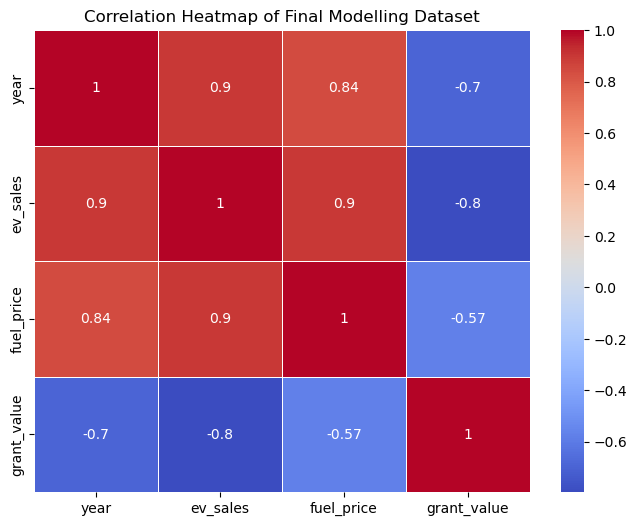

In [82]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Final Modelling Dataset')

plt.show()

### Correlation Heatmap Analysis

The correlation heatmap provides a visual representation of the correlation matrix.

It makes it easier to identify strong positive or negative relationships between variables. In this project, the heatmap is useful for checking how strongly fuel price, year, and grant value are related to EV sales before applying machine learning models.

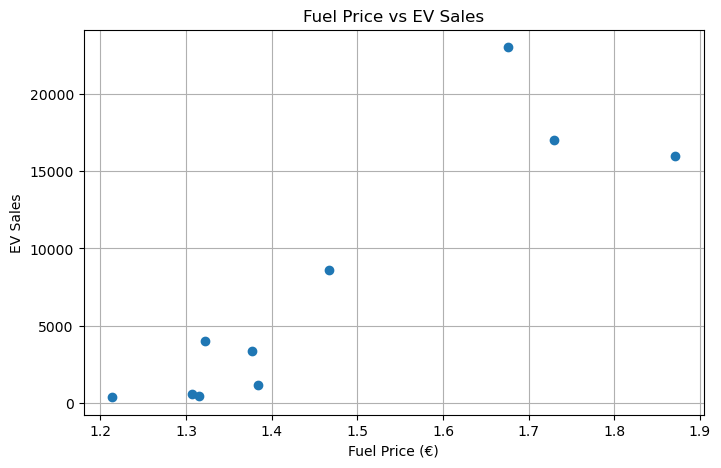

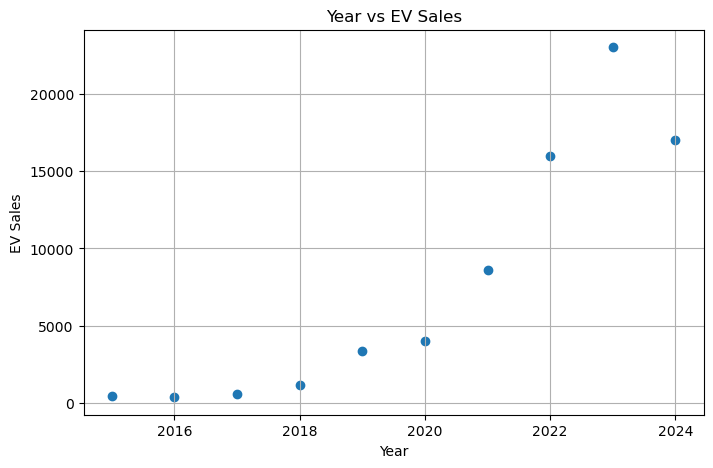

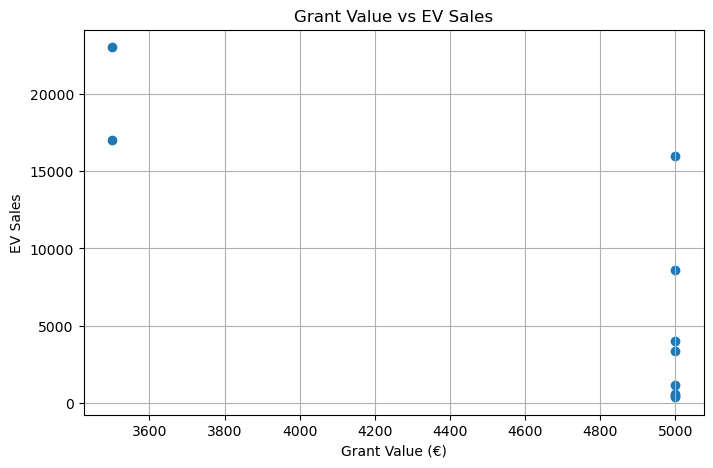

In [84]:
# Scatter Plots: Features vs EV Sales

# Scatter plot: Fuel price vs EV sales
plt.figure(figsize=(8, 5))
plt.scatter(final_model_df['fuel_price'], final_model_df['ev_sales'])
plt.title('Fuel Price vs EV Sales')
plt.xlabel('Fuel Price (€)')
plt.ylabel('EV Sales')
plt.grid()
plt.show()

# Scatter plot: Year vs EV sales
plt.figure(figsize=(8, 5))
plt.scatter(final_model_df['year'], final_model_df['ev_sales'])
plt.title('Year vs EV Sales')
plt.xlabel('Year')
plt.ylabel('EV Sales')
plt.grid()
plt.show()

# Scatter plot: Grant value vs EV sales
plt.figure(figsize=(8, 5))
plt.scatter(final_model_df['grant_value'], final_model_df['ev_sales'])
plt.title('Grant Value vs EV Sales')
plt.xlabel('Grant Value (€)')
plt.ylabel('EV Sales')
plt.grid()
plt.show()

### Scatter Plot Analysis

The scatter plots show the relationship between each individual feature and EV sales.

The fuel price scatter plot helps examine whether higher fuel prices are associated with higher EV sales. The year scatter plot shows the overall growth trend in EV adoption over time. The grant value scatter plot should be interpreted carefully because grant values decreased over time while EV sales increased, which may create a negative relationship in the dataset.

These plots support the feature selection process by showing how each input variable relates to the target variable before model training.

## Final EDA Summary

The exploratory data analysis showed that EV sales in Ireland increased significantly over time, especially in the later years of the dataset. Fuel prices also showed a positive relationship with EV sales, suggesting that higher petrol and diesel prices may be associated with increased EV adoption.

The correlation analysis and scatter plots helped justify the selection of fuel_price, year, and grant_value as features for the machine learning models. However, the grant value relationship should be interpreted with caution because the historical grant value decreased while EV sales increased.

Overall, the EDA supports the modelling stage by showing that the selected variables have meaningful relationships with EV sales, while also highlighting important limitations in the dataset.

## Machine Learning Model Selection

Two types of machine learning models were implemented in this project: Linear Regression and Random Forest Regressor.

Linear Regression was selected because it is simple, interpretable, and suitable for understanding relationships between variables. It provides coefficients, which allow the effect of each feature on EV sales to be explained clearly.

Random Forest Regressor was selected as a comparison model because it can capture more complex, non-linear relationships. It is useful for testing whether a more advanced machine learning method improves prediction performance.

Using both methods allows the project to compare interpretability and predictive accuracy. This supports a stronger final model justification.ication.

# Model 1- Linear Regression (Fuel --> EV Sales)

Intercept: -37327.11259017257
Slope (Coefficient): [29690.54431477]
Model 1 Mean Squared Error: 58059141.493623674
Model 1 R² Score: 0.3566854128130341


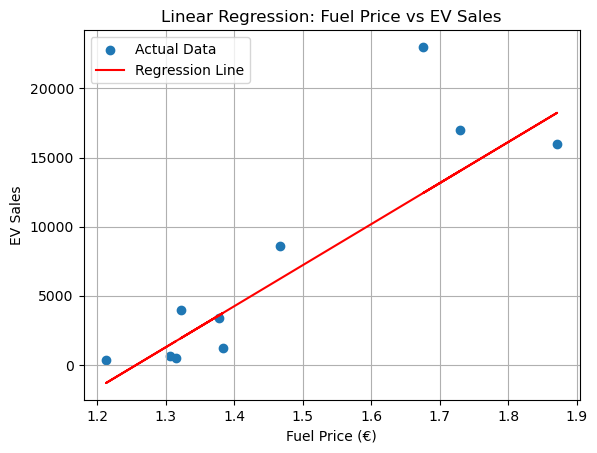

In [88]:
# Preview merged dataset to confirm structure
merged_df.head()

# Ensure dataset is sorted by year (important for time-based analysis)
merged_df = merged_df.sort_values(by='year')

# Independent variable (input feature)
# In this model, use fuel price as the only predictor
X = merged_df[['fuel_price']]

# y = dependent variable (target)
# This is what the project is trying to predict (EV sales)
y = merged_df['ev_sales']


# Train-test split
from sklearn.model_selection import train_test_split

# Split the data into training (80%) and testing (20%) sets
# random_state ensures reproducibility of results
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7
)

# Train model

from sklearn.linear_model import LinearRegression

# Create linear regression model
model = LinearRegression()

# Fit model using training data (learn relationship between X and y)
model.fit(X_train, y_train)


# Predict EV sales using test data
y_pred = model.predict(X_test)


from sklearn.metrics import mean_squared_error, r2_score

# The coefficient represents how much EV sales are expected to change
# for each €1 increase in fuel price
# Display model parameters for interpretation
print("Intercept:", model.intercept_)
print("Slope (Coefficient):", model.coef_)

# Mean Squared Error (MSE)
# Measures average squared difference between predicted and actual values
mse_model_1 = mean_squared_error(y_test, y_pred)

# R² Score
# Measures how well the model explains variation in EV sales (0 = poor, 1 = perfect fit)
r2_model_1 = r2_score(y_test, y_pred)

# Print evaluation results
print("Model 1 Mean Squared Error:", mse_model_1)
print("Model 1 R² Score:", r2_model_1)

# Scatter plot of actual data points
plt.scatter(X, y, label='Actual Data')

# Plot regression line (model predictions across all X values)
plt.plot(X, model.predict(X), color='red', label='Regression Line')

# Labels and title
plt.xlabel('Fuel Price (€)')
plt.ylabel('EV Sales')
plt.title('Linear Regression: Fuel Price vs EV Sales')

# Add legend and grid
plt.legend()
plt.grid()

# Display plot
plt.show()

# NOTE:
# This model uses only one feature (fuel price), so it may not fully capture
# all factors influencing EV adoption (e.g., incentives, infrastructure, technology)

### Model 1 Results: Fuel Price → EV Sales

The linear regression model indicates a positive relationship between fuel prices and EV adoption.

The model coefficient suggests that increases in fuel prices are associated with higher EV sales. This aligns with the expectation that higher fuel costs may encourage consumers to switch to electric vehicles.

However, the model achieves an R² score of approximately 0.36, indicating that fuel price alone explains only a moderate proportion of the variation in EV sales.

This suggests that while fuel prices are a contributing factor, other variables such as government incentives, charging infrastructure, and technological advancements are also likely to play a significant role.

Additionally, both fuel prices and EV sales show upward trends over time, which may contribute to the observed relationship. Therefore, caution should be taken when interpreting this as a purely causal effect.els.icles.

# Model 2: Multiple Linear Regression

In [91]:
# Ensure dataset is sorted by year (important for time-based features)
merged_df = merged_df.sort_values(by='year')

# Define variables
# X = independent variables (multiple features)
# - fuel_price → economic factor
# - year → captures time trend / growth of EV adoption
X = merged_df[['fuel_price', 'year']]

# y = dependent variable (target)
# EV sales we want to predict
y = merged_df['ev_sales']


# Train-test split
from sklearn.model_selection import train_test_split

# Split data into training (80%) and testing (20%)
# random_state ensures consistent results across runs
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7
)

# Train model
from sklearn.linear_model import LinearRegression

# Create regression model
model = LinearRegression()

# Fit model to training data
# The model learns how BOTH features influence EV sales
model.fit(X_train, y_train)

# Predict EV sales on test dataset
y_pred = model.predict(X_test)


# Model evaluation
from sklearn.metrics import mean_squared_error, r2_score

# Mean Squared Error (MSE)
# Measures prediction error (lower is better)
mse_model_2 = mean_squared_error(y_test, y_pred)

# R² Score
# Measures how well the model explains EV sales variation
# Closer to 1 = better model
r2_model_2 = r2_score(y_test, y_pred)

print("Model 2 Mean Squared Error:", mse_model_2)
print("Model 2 R² Score:", r2_model_2)

# Model interpretation
# Intercept = baseline EV sales when all features are 0
print("Intercept:", model.intercept_)

# Coefficients = impact of each feature
# [fuel_price coefficient, year coefficient]
print("Coefficients:", model.coef_)

# Interpretation:
# - fuel_price coefficient → change in EV sales per €1 increase
# - year coefficient → yearly growth effect in EV adoption


# -------------------------------
# Notes / limitations
# -------------------------------

# This model improves on Model 1 by including time (year), which captures underlying growth trends in EV adoption. However, additional factors such as incentives and infrastructure are still not included.

Model 2 Mean Squared Error: 41965203.515416175
Model 2 R² Score: 0.5350115953970507
Intercept: -2086636.0581787473
Coefficients: [17462.50068311  1023.84186857]


### Model 2 Analysis

Model 2 extends the initial linear regression by incorporating both fuel price and year as independent variables to predict EV sales in Ireland. This allows the model to capture not only economic influences but also the underlying time-based growth in EV adoption.

The R² score improved from approximately 0.36 in Model 1 to around 0.54 in Model 2, indicating that the model now explains a greater proportion of the variation in EV sales. This demonstrates that including a time variable significantly improves model performance, as EV adoption is strongly influenced by long-term trends.

The coefficient for fuel price remains positive, suggesting that increases in fuel costs are associated with higher EV sales, likely due to consumers seeking more cost-efficient alternatives. However, this relationship should be interpreted while holding other variables constant.

The year variable also has a positive coefficient, indicating a consistent upward trend in EV adoption over time. This reflects broader structural factors such as technological advancements, increased government support, improved charging infrastructure, and growing environmental awareness.

Despite the improved performance, the model still has limitations. An R² value of 0.54 suggests that a substantial portion of the variation in EV sales remains unexplained. This highlights the importance of additional factors not included in the model, such as government incentives, charging infrastructure availability, vehicle costs, and battery technology improvements.

Overall, Model 2 provides a more realistic and comprehensive representation of EV adoption compared to Model 1, but further enhancements could be achieved by incorporating additional relevanles.vements.

# Model 3: Multiple Linear Regression with Fuel Price, Year and Grant Value

This model expands on Model 2 by adding EV grant value as an additional independent variable. The purpose is to test whether government incentives improve the model’s ability to predict EV sales in Ireland.

The features used in this model are:

- fuel_price: average yearly petrol/diesel price
- year: captures long-term EV adoption trends
- grant_value: represents government financial support for EV purchases

The target variable remains EV sales.

In [94]:
# Model 3: Fuel Price + Year + Grant Value

# Ensure final dataset is sorted by year
final_model_df = final_model_df.sort_values(by='year')

# Define independent variables
# These are the factors used to predict EV sales
X = final_model_df[['fuel_price', 'year', 'grant_value']]

# Define dependent variable
# This is the target the model is trying to predict
y = final_model_df['ev_sales']

# Import train-test split
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
# 80% of the data is used for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7
)

# Import Linear Regression model
from sklearn.linear_model import LinearRegression

# Create the model
model_3 = LinearRegression()

# Train the model using the training data
model_3.fit(X_train, y_train)

# Predict EV sales using the test data
y_pred = model_3.predict(X_test)

# Import evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score

# Calculate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display results
print("Mean Squared Error:", mse)
print("R² Score:", r2)

# Display model parameters
print("Intercept:", model_3.intercept_)
print("Coefficients:", model_3.coef_)

# Show coefficients beside feature names for easier interpretation
coefficients_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model_3.coef_
})

coefficients_df

Mean Squared Error: 30209100.130862743
R² Score: 0.6652731287439031
Intercept: -1562466.362772879
Coefficients: [ 1.86936652e+04  7.67198265e+02 -1.62103435e+00]


,Feature,Coefficient
0,fuel_price,18693.665198
1,year,767.198265
2,grant_value,-1.621034


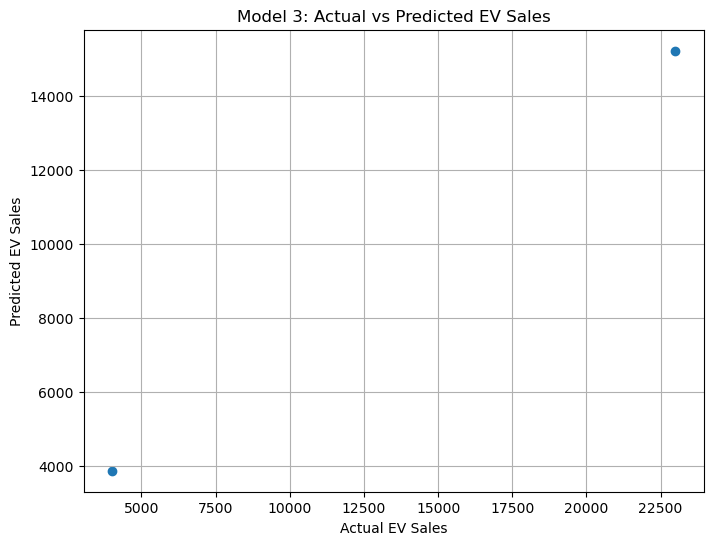

In [95]:
# Plot actual vs predicted EV sales

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual EV Sales')
plt.ylabel('Predicted EV Sales')
plt.title('Model 3: Actual vs Predicted EV Sales')

plt.grid()

plt.show()

## Model 3 Analysis

Model 3 used fuel price, year, and grant value to predict EV sales. The R² score was approximately 0.67, meaning the model explained around 67% of the variation in the test data.

However, this result should be interpreted carefully because the dataset is very small and the test set only contains a small number of years. The actual vs predicted graph only shows two points because 20% of the dataset was used for testing.

The model suggests that adding grant value provides another useful policy-related variable, but it does not prove that grants directly caused changes in EV sales.

# Model 4: Random Forest Regressor

A Random Forest Regressor was also implemented to compare Linear Regression with a different machine learning method.

Unlike Linear Regression, which assumes a straight-line relationship between the input variables and EV sales, Random Forest can capture more complex non-linear patterns. This makes it useful as a comparison model.

The same features from Model 3 are used:

- fuel_price
- year
- grant_value

The target variable remains EV sales.

This model will help justify whether Linear Regression or Random Forest is more suitable for the final project.

In [98]:
# Model 4: Random Forest Regressor
# Import Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Import evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score

# Ensure final dataset is sorted by year
final_model_df = final_model_df.sort_values(by='year')

# Define independent variables
# These are the features used to predict EV sales
X = final_model_df[['fuel_price', 'year', 'grant_value']]

# Define dependent variable
# This is the value the model is trying to predict
y = final_model_df['ev_sales']

# Split the dataset into training and testing data
# The same random_state is used so results are consistent
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7
)

# Create the Random Forest model
# n_estimators means the number of decision trees used in the forest
model_4 = RandomForestRegressor(
    n_estimators=100,
    random_state=7
)

# Train the model
model_4.fit(X_train, y_train)

# Make predictions using the test data
y_pred_rf = model_4.predict(X_test)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Display results
print("Random Forest Mean Squared Error:", mse_rf)
print("Random Forest R² Score:", r2_rf)

Random Forest Mean Squared Error: 26872621.22
Random Forest R² Score: 0.7022424241551246


In [99]:
# Random Forest Feature Importance

# Create a dataframe showing feature importance
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_4.feature_importances_
})

# Sort from most important to least important
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Display feature importance
feature_importance_df

,Feature,Importance
0,fuel_price,0.486128
1,year,0.475836
2,grant_value,0.038036


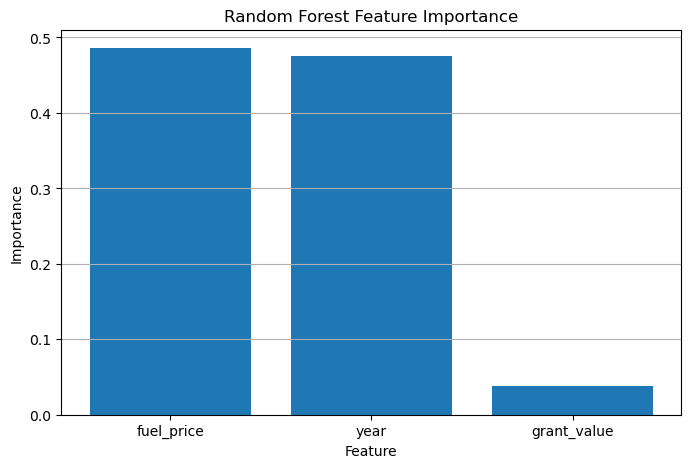

In [100]:
# Plot Random Forest feature importance
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance_df['Feature'],
    feature_importance_df['Importance']
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importance')

plt.grid(axis='y')

plt.show()

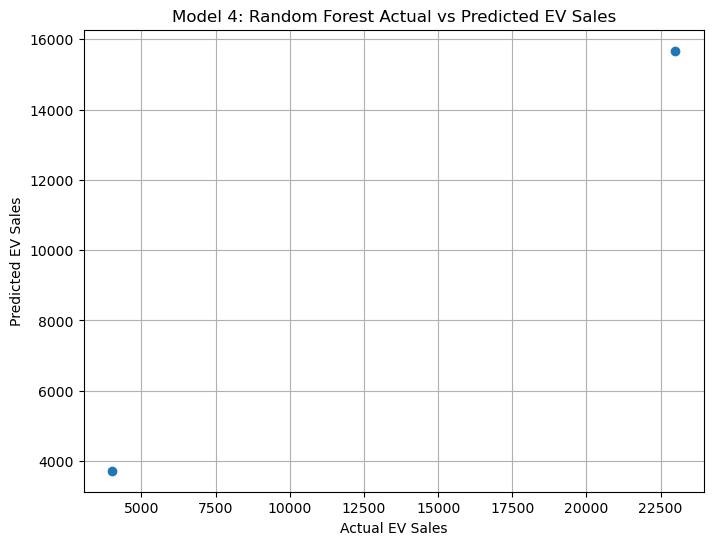

In [101]:
# Plot actual vs predicted EV sales for Random Forest

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf)

plt.xlabel('Actual EV Sales')
plt.ylabel('Predicted EV Sales')
plt.title('Model 4: Random Forest Actual vs Predicted EV Sales')

plt.grid()

plt.show()

## Model 4 Analysis

The Random Forest Regressor was implemented to compare Linear Regression with a more complex machine learning method. Random Forest can model non-linear relationships and interactions between variables, while Linear Regression assumes a simpler linear relationship.

The model used the same features as Model 3: fuel price, year, and grant value.

The Random Forest model achieved a Mean Squared Error of approximately 2,687,621 and an R² score of approximately 0.70. This means it performed slightly better than the multiple Linear Regression model, which achieved an R² score of approximately 0.67.

The feature importance output shows that fuel price and year were the most influential variables in the Random Forest predictions, while grant value had a much smaller importance score. This suggests that, within this dataset, fuel prices and time-related adoption trends had a stronger relationship with EV sales than grant value.

However, the results should be interpreted carefully because the dataset is very small. The test set only contains a small number of years, so the R² score can change significantly depending on which years are selected for testing.

Even though Random Forest performed slightly better, Linear Regression may still be more suitable as the final model because it is easier to interpret and explain. This is important for this project because the aim is not only prediction, but also understanding how fuel prices, grants, and time relate to EV adoption. adoption.

# Model Comparison and Final Model Selection

This section compares the performance of all machine learning models implemented in the project.

The purpose of this comparison is to evaluate whether adding more features improves prediction performance, and whether a more complex machine learning model such as Random Forest provides better results than Linear Regression.

The models are compared using two evaluation metrics:

- Mean Squared Error (MSE): measures the average squared difference between actual and predicted values. A lower MSE indicates better performance.
- R² Score: measures how much variation in EV sales is explained by the model. A higher R² score indicates better performance.

In [104]:
# Model Comparison Table

# Create a table comparing all models
model_comparison_df = pd.DataFrame({
    'Model': [
        'Model 1: Linear Regression',
        'Model 2: Multiple Linear Regression',
        'Model 3: Multiple Linear Regression + Grant Value',
        'Model 4: Random Forest Regressor'
    ],
    
    'Features Used': [
        'fuel_price',
        'fuel_price, year',
        'fuel_price, year, grant_value',
        'fuel_price, year, grant_value'
    ],
    
    'Mean Squared Error': [
        mse_model_1,
        mse_model_2,
        mse,
        mse_rf
    ],
    
    'R² Score': [
        r2_model_1,
        r2_model_2,
        r2,
        r2_rf
    ]
})

# Display comparison table
model_comparison_df

,Model,Features Used,Mean Squared Error,R² Score
0,Model 1: Linear Regression,fuel_price,5.805914e+07,0.356685
1,Model 2: Multiple Linear Regression,"fuel_price, year",4.196520e+07,0.535012
2,Model 3: Multiple Linear Regression + Grant Value,"fuel_price, year, grant_value",3.020910e+07,0.665273
3,Model 4: Random Forest Regressor,"fuel_price, year, grant_value",2.687262e+07,0.702242


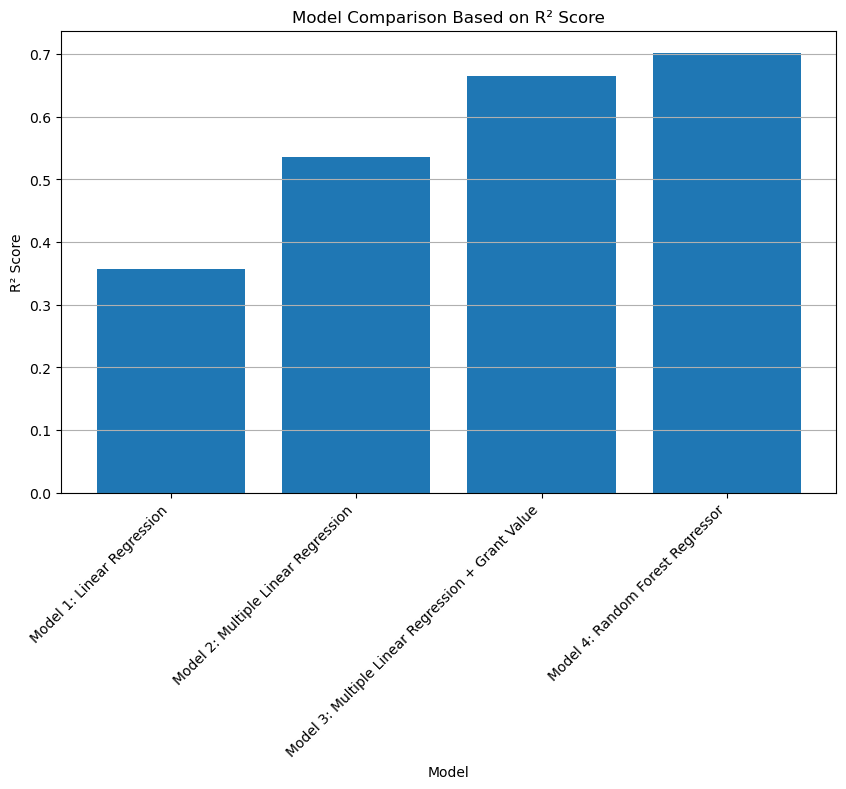

In [105]:
# Plot R² scores for each model

plt.figure(figsize=(10, 6))

plt.bar(
    model_comparison_df['Model'],
    model_comparison_df['R² Score']
)

plt.title('Model Comparison Based on R² Score')
plt.xlabel('Model')
plt.ylabel('R² Score')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

plt.show()

## Model Comparison Analysis

The model comparison table shows that prediction performance improved as additional features were added to the Linear Regression models.

Model 1 used only fuel price and produced the weakest results. This suggests that fuel price alone is not enough to explain EV adoption trends in Ireland.

Model 2 improved performance by adding year as a feature. This indicates that EV adoption is strongly influenced by time-based trends, such as growing public awareness, increasing EV availability, improving technology, and wider market acceptance.

Model 3 added grant value and achieved a further improvement. This suggests that government incentives may provide useful additional context when predicting EV sales, although the relationship should be interpreted carefully.

Model 4, the Random Forest Regressor, achieved the highest R² score and lowest Mean Squared Error. This shows that Random Forest performed slightly better in terms of prediction accuracy.

However, Linear Regression remains valuable because it is easier to interpret. The coefficients allow the relationship between each feature and EV sales to be explained more clearly. This is important because the purpose of the project is not only to predict EV sales, but also to understand how fuel prices, grants, and time relate to EV adoption.

For this reason, the final model selection should consider both predictive performance and interpretability.

# Scenario Simulation Prototype

This section develops a simple scenario simulation prototype using the final Linear Regression model.

The purpose of the simulation is to estimate how EV sales could change under different conditions, such as changes in fuel prices, government grant values, and future years.

This turns the machine learning model into a basic decision-support tool. Instead of only analysing historical data, the model can be used to explore possible future outcomes.

The scenario simulation uses the following inputs:

- fuel_price: estimated average annual fuel price
- year: future or selected year
- grant_value: estimated EV grant amount

The output is the predicted number of EV sales.

In [108]:
# Scenario Simulation Prototype

# Create a dataframe with different possible future scenarios
scenario_df = pd.DataFrame({
    'Scenario': [
        'Baseline 2025',
        'Higher Fuel Price',
        'Lower Fuel Price',
        'Grant Increased',
        'Grant Reduced',
        'Future Growth 2026'
    ],
    
    'fuel_price': [
        1.80,   # baseline estimated fuel price
        2.00,   # higher fuel price scenario
        1.60,   # lower fuel price scenario
        1.80,   # same fuel price, higher grant
        1.80,   # same fuel price, lower grant
        1.85    # future year estimate
    ],
    
    'year': [
        2025,
        2025,
        2025,
        2025,
        2025,
        2026
    ],
    
    'grant_value': [
        3500,   # current/recent grant value assumption
        3500,
        3500,
        5000,   # increased grant scenario
        2500,   # reduced grant scenario
        3500
    ]
})

# Display the scenario input table
scenario_df

,Scenario,fuel_price,year,grant_value
0,Baseline 2025,1.80,2025,3500
1,Higher Fuel Price,2.00,2025,3500
2,Lower Fuel Price,1.60,2025,3500
3,Grant Increased,1.80,2025,5000
4,Grant Reduced,1.80,2025,2500
5,Future Growth 2026,1.85,2026,3500


In [109]:
# Predict EV Sales for Each Scenario

# Select only the feature columns used by Model 3
scenario_features = scenario_df[['fuel_price', 'year', 'grant_value']]

# Use Model 3 to predict EV sales for each scenario
scenario_predictions = model_3.predict(scenario_features)

# Add predictions to the scenario dataframe
scenario_df['predicted_ev_sales'] = scenario_predictions

# Round predicted EV sales to whole numbers
scenario_df['predicted_ev_sales'] = scenario_df['predicted_ev_sales'].round(0).astype(int)

# Display scenario results
scenario_df

,Scenario,fuel_price,year,grant_value,predicted_ev_sales
0,Baseline 2025,1.80,2025,3500,19085
1,Higher Fuel Price,2.00,2025,3500,22824
2,Lower Fuel Price,1.60,2025,3500,15346
3,Grant Increased,1.80,2025,5000,16654
4,Grant Reduced,1.80,2025,2500,20706
5,Future Growth 2026,1.85,2026,3500,20787


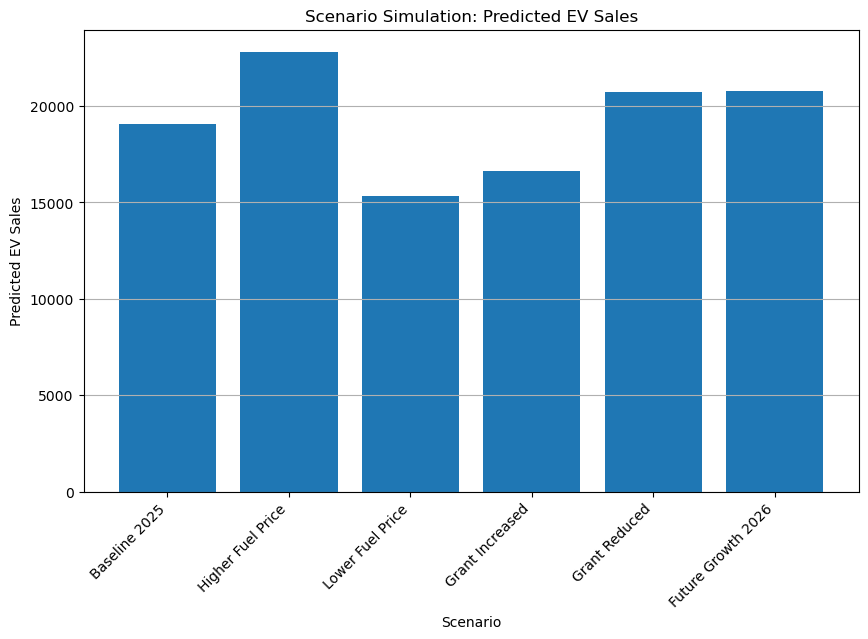

In [110]:
# Scenario Simulation Graph

plt.figure(figsize=(10, 6))

plt.bar(
    scenario_df['Scenario'],
    scenario_df['predicted_ev_sales']
)

plt.title('Scenario Simulation: Predicted EV Sales')
plt.xlabel('Scenario')
plt.ylabel('Predicted EV Sales')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

plt.show()

## Scenario Simulation Analysis

The scenario simulation prototype uses the trained Linear Regression model to estimate EV sales under different future conditions.

The baseline scenario estimates EV sales for 2025 using an assumed fuel price of €1.80 and a grant value of €3,500. Other scenarios adjust one variable at a time, such as increasing fuel prices, lowering fuel prices, increasing the grant, or reducing the grant.

The fuel price scenarios show an intuitive pattern. When fuel prices are increased, predicted EV sales also increase. When fuel prices are reduced, predicted EV sales decrease. This suggests that, according to the model, higher petrol and diesel prices may be associated with greater EV adoption.

The grant scenarios should be interpreted carefully. The model predicts lower EV sales when the grant value is increased, and higher EV sales when the grant value is reduced. This does not mean that grants cause EV sales to decrease. Instead, this result is likely caused by the historical pattern in the dataset, where EV grant values decreased over time while EV sales continued to increase. This highlights an important limitation of the model.

The scenario simulation acts as a basic decision-support prototype. It allows different assumptions about fuel prices, grant values, and future years to be tested. However, because the dataset is small and the model captures correlation rather than causation, the predictions should be treated as exploratory rather than definitive.

# Scenario Visualisations

This section expands the scenario simulation prototype by creating separate visualisations for different types of changes.

The purpose is to make the simulation easier to interpret by separating the impact of fuel price changes, grant value changes, and future year assumptions.

These visualisations help show how the trained model responds when individual input values are adjusted.

In [113]:
# Fuel Price Scenario Visualisation

# Create a range of possible fuel prices for 2025
fuel_scenario_df = pd.DataFrame({
    'fuel_price': [1.50, 1.60, 1.70, 1.80, 1.90, 2.00, 2.10],
    'year': [2025, 2025, 2025, 2025, 2025, 2025, 2025],
    'grant_value': [3500, 3500, 3500, 3500, 3500, 3500, 3500]
})

# Predict EV sales using Model 3
fuel_scenario_df['predicted_ev_sales'] = model_3.predict(
    fuel_scenario_df[['fuel_price', 'year', 'grant_value']]
)

# Round predictions to whole numbers
fuel_scenario_df['predicted_ev_sales'] = fuel_scenario_df['predicted_ev_sales'].round(0).astype(int)

# Display fuel scenario table
fuel_scenario_df

,fuel_price,year,grant_value,predicted_ev_sales
0,1.5,2025,3500,13477
1,1.6,2025,3500,15346
2,1.7,2025,3500,17216
3,1.8,2025,3500,19085
4,1.9,2025,3500,20954
5,2.0,2025,3500,22824
6,2.1,2025,3500,24693


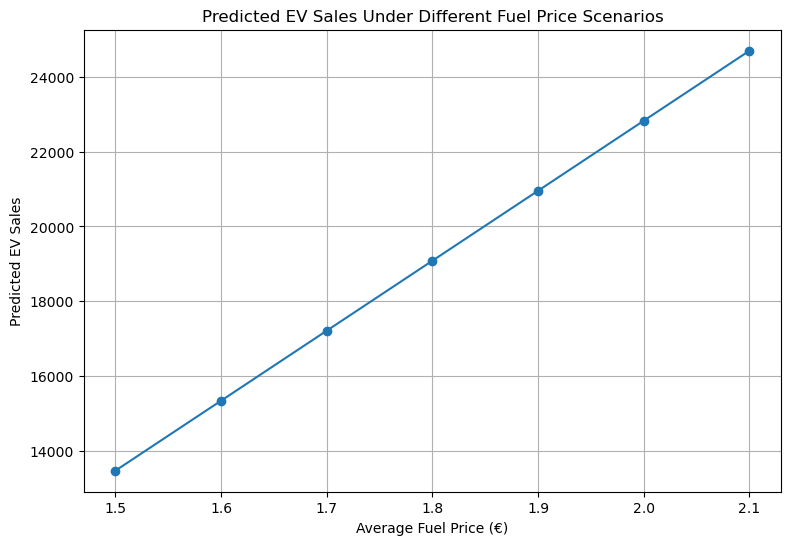

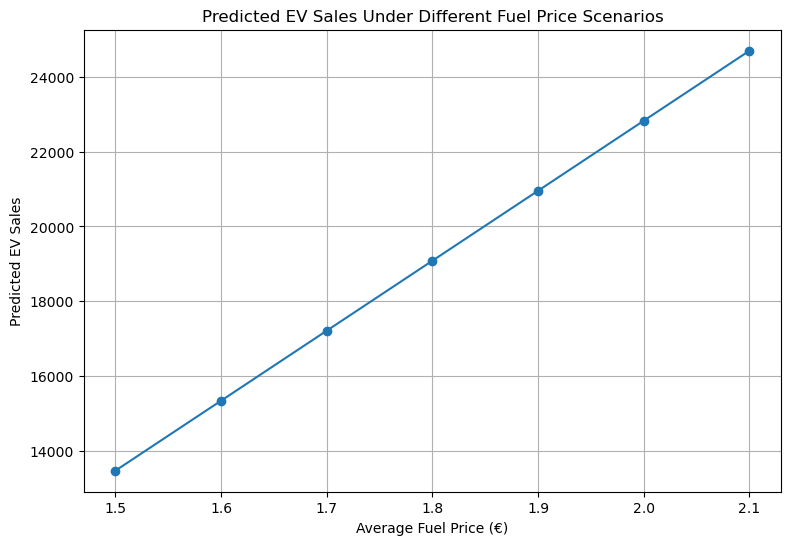

In [114]:
# Plot predicted EV sales under different fuel prices
plt.figure(figsize=(9, 6))

plt.plot(
    fuel_scenario_df['fuel_price'],
    fuel_scenario_df['predicted_ev_sales'],
    marker='o'
)

plt.title('Predicted EV Sales Under Different Fuel Price Scenarios')
plt.xlabel('Average Fuel Price (€)')
plt.ylabel('Predicted EV Sales')

plt.grid()

plt.show()# Plot predicted EV sales under different fuel prices

plt.figure(figsize=(9, 6))

plt.plot(
    fuel_scenario_df['fuel_price'],
    fuel_scenario_df['predicted_ev_sales'],
    marker='o'
)

plt.title('Predicted EV Sales Under Different Fuel Price Scenarios')
plt.xlabel('Average Fuel Price (€)')
plt.ylabel('Predicted EV Sales')

plt.grid()

plt.show()

## Fuel Price Scenario Analysis

The fuel price scenario visualisation shows how predicted EV sales change when the average fuel price is adjusted while keeping the year and grant value constant.

According to the model, higher fuel prices are associated with higher predicted EV sales. This suggests that when petrol and diesel become more expensive, EVs may become more attractive to consumers.

This result is consistent with the idea that running costs can influence vehicle purchasing decisions. However, this should still be interpreted as an association rather than direct causation.

In [116]:
# Grant Value Scenario Visualisation

# Create a range of possible grant values for 2025
grant_scenario_df = pd.DataFrame({
    'fuel_price': [1.80, 1.80, 1.80, 1.80, 1.80, 1.80],
    'year': [2025, 2025, 2025, 2025, 2025, 2025],
    'grant_value': [2000, 2500, 3000, 3500, 4000, 5000]
})

# Predict EV sales using Model 3
grant_scenario_df['predicted_ev_sales'] = model_3.predict(
    grant_scenario_df[['fuel_price', 'year', 'grant_value']]
)

# Round predictions to whole numbers
grant_scenario_df['predicted_ev_sales'] = grant_scenario_df['predicted_ev_sales'].round(0).astype(int)

# Display grant scenario table
grant_scenario_df

,fuel_price,year,grant_value,predicted_ev_sales
0,1.8,2025,2000,21517
1,1.8,2025,2500,20706
2,1.8,2025,3000,19896
3,1.8,2025,3500,19085
4,1.8,2025,4000,18275
5,1.8,2025,5000,16654


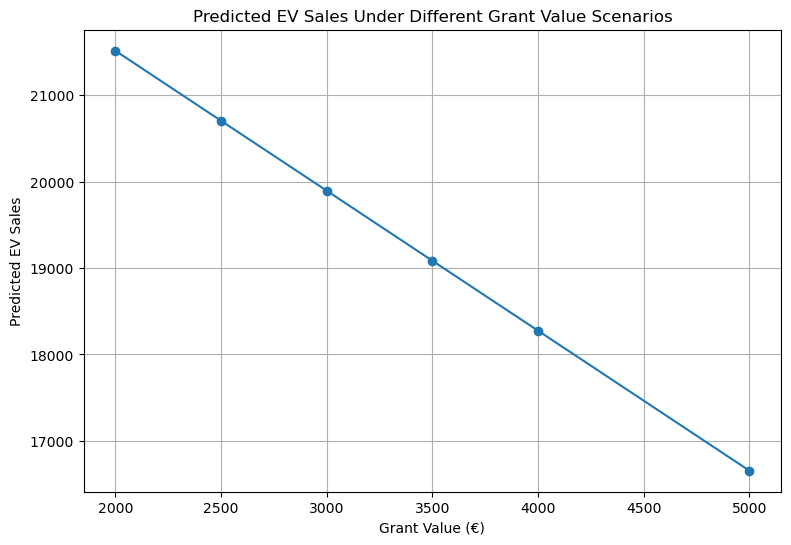

In [117]:
# Plot predicted EV sales under different grant values
plt.figure(figsize=(9, 6))

plt.plot(
    grant_scenario_df['grant_value'],
    grant_scenario_df['predicted_ev_sales'],
    marker='o'
)

plt.title('Predicted EV Sales Under Different Grant Value Scenarios')
plt.xlabel('Grant Value (€)')
plt.ylabel('Predicted EV Sales')

plt.grid()

plt.show()

## Grant Value Scenario Analysis

The grant value scenario visualisation shows how predicted EV sales change when the grant value is adjusted while keeping fuel price and year constant.

The model predicts lower EV sales as grant values increase. This result should be interpreted carefully. It does not mean that increasing grants causes EV sales to decrease.

Instead, this pattern is likely caused by the historical data used to train the model. In the dataset, EV grant values decreased over time while EV sales continued to increase. As a result, the model learned a negative association between grant value and EV sales.

This highlights one of the limitations of the model: it captures historical correlations, but it does not fully understand policy causation or wider market behaviour.

In [119]:
# ================================
# Future Year Scenario Visualisation
# ================================

# Create future year scenarios using fixed fuel price and grant value
future_scenario_df = pd.DataFrame({
    'fuel_price': [1.80, 1.80, 1.80, 1.80, 1.80],
    'year': [2025, 2026, 2027, 2028, 2029],
    'grant_value': [3500, 3500, 3500, 3500, 3500]
})

# Predict EV sales using Model 3
future_scenario_df['predicted_ev_sales'] = model_3.predict(
    future_scenario_df[['fuel_price', 'year', 'grant_value']]
)

# Round predictions to whole numbers
future_scenario_df['predicted_ev_sales'] = future_scenario_df['predicted_ev_sales'].round(0).astype(int)

# Display future scenario table
future_scenario_df

,fuel_price,year,grant_value,predicted_ev_sales
0,1.8,2025,3500,19085
1,1.8,2026,3500,19852
2,1.8,2027,3500,20619
3,1.8,2028,3500,21387
4,1.8,2029,3500,22154


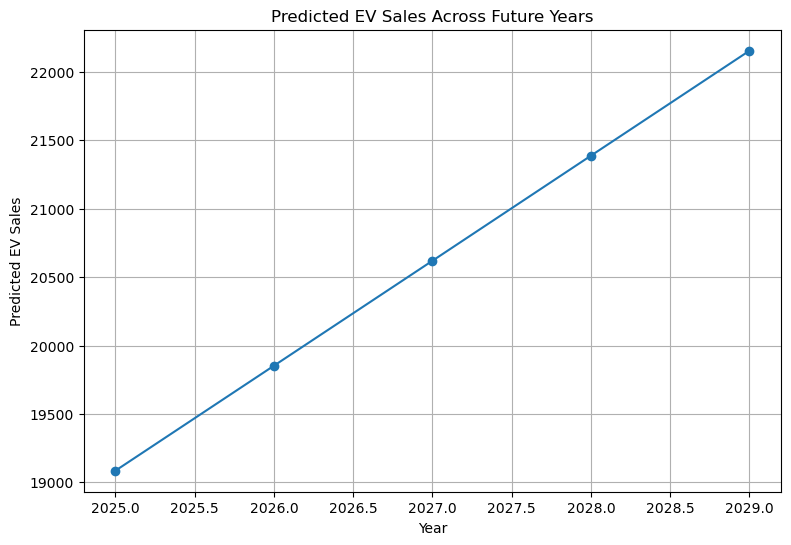

In [120]:
# Plot predicted EV sales across future years
plt.figure(figsize=(9, 6))

plt.plot(
    future_scenario_df['year'],
    future_scenario_df['predicted_ev_sales'],
    marker='o'
)

plt.title('Predicted EV Sales Across Future Years')
plt.xlabel('Year')
plt.ylabel('Predicted EV Sales')

plt.grid()

plt.show()

## Future Year Scenario Analysis

The future year scenario visualisation estimates predicted EV sales from 2025 to 2029 while keeping fuel price and grant value constant.

The model predicts a gradual increase in EV sales over time. This is mainly because the year feature captures the overall upward trend in EV adoption found in the historical data.

This suggests that, according to the model, EV adoption is expected to continue increasing if previous trends continue. However, future predictions should be treated cautiously because real-world EV adoption may be affected by factors not included in the model, such as charging infrastructure, vehicle prices, electricity prices, policy changes, and consumer confidence.

## Scenario Visualisation Summary

The scenario visualisations provide a clearer view of how the model responds to different input changes.

The fuel price scenario suggests that higher fuel prices are associated with higher predicted EV sales. The grant value scenario highlights a limitation in the model, as it reflects historical correlation rather than policy causation. The future year scenario suggests that EV sales may continue to increase over time if previous adoption trends continue.

Together, these visualisations strengthen the prototype element of the project by allowing possible future conditions to be tested and interpreted visually.

# Project Limitations

This project has several important limitations.

First, the final modelling dataset is small because it is based on annual data. This means the model only has a limited number of observations to learn from. As a result, performance scores such as R² and Mean Squared Error should be interpreted cautiously.

Second, the model captures correlation rather than causation. For example, the model can identify that fuel prices and EV sales move together, but it cannot prove that higher fuel prices directly caused higher EV adoption.

Third, the grant value feature has a complex relationship with EV sales. In the historical data, grant values decreased while EV sales increased. This creates a negative relationship in the model, but it should not be interpreted as evidence that grants reduce EV adoption.

Fourth, other important factors were not included in the final model, such as charging infrastructure, electricity prices, EV purchase prices, household income, vehicle availability, and public attitudes.

Finally, future predictions are uncertain because market conditions, government policy, technology, and consumer behaviour can change over time.

These limitations mean that the model should be used as an exploratory decision-support prototype rather than a definitive forecasting tool.

# Final Conclusion

This project analysed electric vehicle adoption in Ireland using exploratory data analysis and machine learning.

The EDA showed that EV sales increased significantly over time and that fuel prices had a strong positive relationship with EV sales in the final modelling dataset. Grant value showed a negative relationship with EV sales, but this was interpreted carefully because grant values decreased while EV adoption continued to rise.

Several machine learning models were implemented and compared. The Linear Regression models showed that prediction performance improved as additional features were added. The Random Forest Regressor achieved the strongest predictive performance overall, but Linear Regression remained more interpretable.

The scenario simulation prototype demonstrated how the trained model could be used to explore possible future conditions, such as changes in fuel prices, grant values, and future years. This supports the project aim of creating a basic decision-support tool.

Overall, the project shows that data analytics and machine learning can provide useful insight into EV adoption trends. However, the results should be interpreted cautiously due to the small dataset size and the fact that the models identify relationships rather than direct causation.